# SmartChild Chatbot — Full Fine-Tuning Pipeline

**Two-mode chatbot for SmartChild platform:**
- **Sunny Mode** — Friendly star character for children
- **Parent Advisor Mode** — Warm child development advisor for parents

---

## Datasets Used

| Dataset | HuggingFace Link | Purpose | Mode |
|---------|-----------------|---------|------|
| EmpatheticDialogues (LLM-ready) | `Estwld/empathetic_dialogues_llm` | Emotional response tone | Both |
| Everyday Conversations | `HuggingFaceTB/everyday-conversations-llama3.1-2k` | Natural chat behavior | Child |
| Children Stories Collection | `ajibawa-2023/Children-Stories-Collection` | Child vocabulary & tone | Child |
| TinyStories | `roneneldan/TinyStories` | Simple child-level language | Child |
| Mental Health Counseling | `Amod/mental_health_counseling_conversations` | Warm advisor tone | Parent |
| Empathetic Counseling | `LuangMV97/Empathetic_counseling_Dataset` | Non-diagnostic empathy | Parent |
| SmartChild Custom Dataset | Local JSONL | App-specific knowledge | Both |

---

## Pipeline Overview
```
1. Environment Setup
2. Load All Datasets
3. Explore & Analyze Each Dataset
4. Clean & Filter Each Dataset
5. Transform to Unified Chat Format
6. Merge + Balance Final Dataset
7. Quality Validation & Statistics
8. Fine-Tune with Unsloth + LoRA
9. Evaluate & Save Model
10. Upload to HuggingFace Hub
11. Download Locally & Run Flask Backend
```

---
## CELL 1 — Environment Setup & GPU Check

In [ ]:
!pip install -q unsloth transformers datasets trl peft accelerate bitsandbytes
!pip install -q pandas numpy matplotlib seaborn scikit-learn langdetect
!pip install -q sentencepiece protobuf huggingface_hub
print("All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 868.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.4/924.4 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch

print("=" * 60)
print(" RUNTIME INFORMATION")
print("=" * 60)
if torch.cuda.is_available():
    print(f" GPU : {torch.cuda.get_device_name(0)}")
    print(f" VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("No GPU — switch Runtime to GPU!")
print(f" PyTorch: {torch.__version__}")
print("=" * 60)

 RUNTIME INFORMATION
 GPU : Tesla T4
 VRAM: 15.6 GB
 PyTorch: 2.10.0+cu128


In [ ]:
import os, re, json, random, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset, Dataset
from langdetect import detect, LangDetectException

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
PALETTE = ["#4A90D9", "#F5A623", "#7ED321", "#D0021B", "#9B59B6", "#1ABC9C", "#E67E22"]
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print(" Imports ready")

 Imports ready


In [ ]:
CFG = {
    "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
    "max_seq_length": 1024,
    "load_in_4bit": True,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "epochs": 5,
    "batch_size": 2,
    "grad_accum": 4,
    "lr": 2e-4,
    "warmup_ratio": 0.05,
    "weight_decay": 0.01,
    # ── Dataset limits (how many examples to sample from each source) ────────
    "empathetic_limit": 2000,  # EmpatheticDialogues  → both modes
    "everyday_limit": 2000,  # Everyday Conversations → child mode
    "stories_limit": 1500,  # Children Stories       → child/story mode
    "tinystories_limit": 1000,  # TinyStories            → child/story mode
    "counseling_limit": 2000,  # Mental Health Counseling → parent mode
    "emp_counsel_limit": 1000,  # Empathetic Counseling    → parent mode
    # ── Output ───────────────────────────────────────────────────────────────
    "output_dir": "./smartchild-model",
}
print(" Configuration loaded")
print(json.dumps({k: v for k, v in CFG.items()}, indent=2))

 Configuration loaded
{
  "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
  "max_seq_length": 1024,
  "load_in_4bit": true,
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "epochs": 5,
  "batch_size": 2,
  "grad_accum": 4,
  "lr": 0.0002,
  "warmup_ratio": 0.05,
  "weight_decay": 0.01,
  "empathetic_limit": 2000,
  "everyday_limit": 2000,
  "stories_limit": 1500,
  "tinystories_limit": 1000,
  "counseling_limit": 2000,
  "emp_counsel_limit": 1000,
  "output_dir": "./smartchild-model"
}


---
## CELL 2 — Load All Datasets

In [ ]:
def safe_load(name, split="train", **kwargs):
    try:
        ds = load_dataset(name, split=split, trust_remote_code=True, **kwargs)
        print(f" {name:50s} → {len(ds):>7,} rows")
        return ds
    except Exception as e:
        print(f" {name}: {e}")
        return None


print("=" * 60 + "\n LOADING DATASETS\n" + "=" * 60)
ds_empathetic = safe_load("Estwld/empathetic_dialogues_llm")
ds_everyday = safe_load("HuggingFaceTB/everyday-conversations-llama3.1-2k")
ds_stories = safe_load(
    "ajibawa-2023/Children-Stories-Collection", data_files="data-stories-1.json"
)
ds_tinystories = safe_load("roneneldan/TinyStories")
ds_counseling = safe_load("Amod/mental_health_counseling_conversations")
ds_emp_counsel = safe_load("LuangMV97/Empathetic_counseling_Dataset")
print("=" * 60 + "\nAll datasets loaded ")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Estwld/empathetic_dialogues_llm' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Estwld/empathetic_dialogues_llm' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


 LOADING DATASETS


README.md:   0%|          | 0.00/3.28k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.22M [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/806k [00:00<?, ?B/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/8.26M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30937 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7736 [00:00<?, ? examples/s]

 LuangMV97/Empathetic_counseling_Dataset            →  30,937 rows
All datasets loaded 


---
## CELL 3 — Explore & Analyze

In [ ]:
import pandas as pd
from IPython.display import display


def explore(ds, name, sample=2):
    if ds is None:
        print(f"{name} not loaded")
        return
    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    print(f"Rows: {len(ds):,}  Columns: {ds.column_names}")
    df = pd.DataFrame(ds.select(range(min(sample, len(ds)))))
    display(df)


for ds, name in [
    (ds_empathetic, "EmpatheticDialogues"),
    (ds_everyday, "Everyday"),
    (ds_stories, "Children Stories"),
    (ds_tinystories, "TinyStories"),
    (ds_counseling, "Counseling"),
    (ds_emp_counsel, "Emp.Counseling"),
]:
    explore(ds, name)


  EmpatheticDialogues
Rows: 19,533  Columns: ['conv_id', 'situation', 'emotion', 'conversations']


,conv_id,situation,emotion,conversations
0,hit:0_conv:1,I remember going to the fireworks with my best...,sentimental,[{'content': 'I remember going to see the fire...
1,hit:1_conv:2,i used to scare for darkness,afraid,[{'content': ' it feels like hitting to blank ...


Everyday not loaded
Children Stories not loaded

  TinyStories
Rows: 2,119,719  Columns: ['text']


,text
0,"One day, a little girl named Lily found a need..."
1,"Once upon a time, there was a little car named..."



  Counseling
Rows: 3,512  Columns: ['Context', 'Response']


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."



  Emp.Counseling
Rows: 30,937  Columns: ['input', 'label']


,input,label
0,I am so annoyed at president Trump.,I guess thats a reason
1,A Groundhog made his way under my deck and had...,Do you have any pets of your own? you sound li...


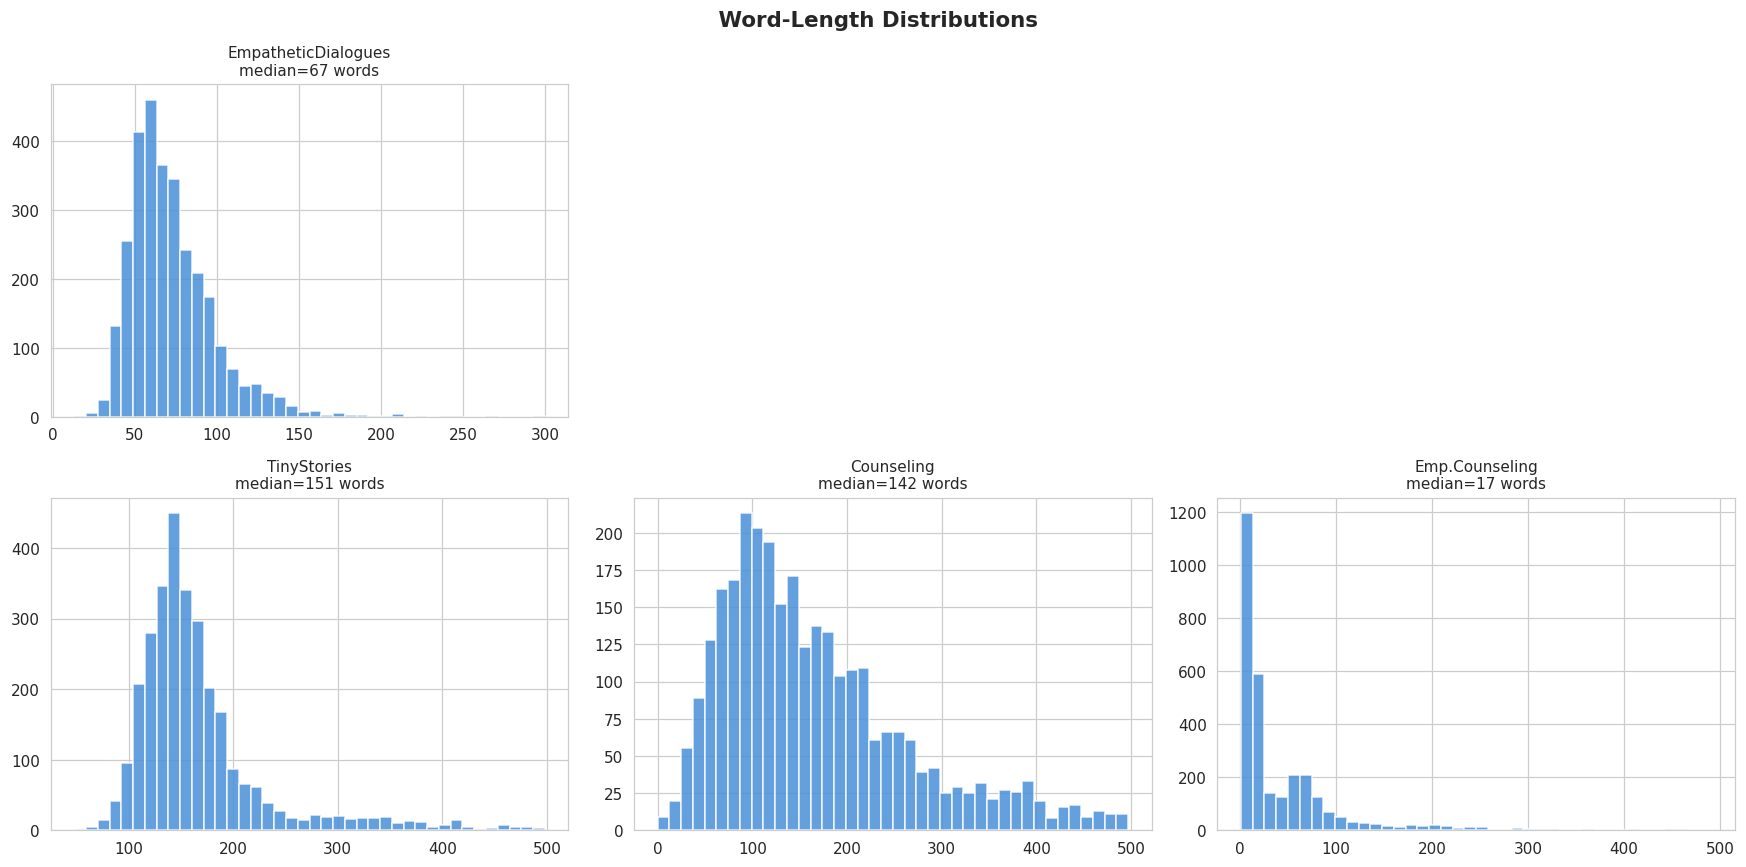

In [ ]:
def get_wc(ds, col, n=3000):
    s = ds.select(range(min(n, len(ds))))
    return [len(str(r[col]).split()) for r in s]


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(" Word-Length Distributions", fontsize=14, fontweight="bold")
axes = axes.flatten()
infos = [
    (ds_empathetic, "EmpatheticDialogues", "conversations"),
    (ds_everyday, "Everyday", "messages"),
    (ds_stories, "Children Stories", "text"),
    (ds_tinystories, "TinyStories", "text"),
    (ds_counseling, "Counseling", "Response"),
    (ds_emp_counsel, "Emp.Counseling", "label"),
]
for ax, (ds, name, col) in zip(axes, infos):
    if ds is None:
        ax.set_visible(False)
        continue
    try:
        wc = [w for w in get_wc(ds, col) if w < 500]
        ax.hist(wc, bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
        ax.set_title(f"{name}\nmedian={int(np.median(wc))} words", fontsize=10)
    except Exception as e:
        ax.set_title(f"{name}\nerror:{e}", fontsize=9)
plt.tight_layout()
plt.savefig("word_distributions.png", bbox_inches="tight")
plt.show()

---
## CELL 4 — Cleaning & Filtering Functions

In [ ]:
import unicodedata
import re


def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Normalize unicode characters
    text = unicodedata.normalize("NFKC", text)
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)
    # Remove unusual invisible/control characters
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]", "", text)
    text = text.replace("_comma_", ",").replace("\u200b", "").replace("\u00a0", " ")
    # Collapse multiple whitespaces
    text = re.sub(r"\s+", " ", text).strip()
    return text


def word_count(text):
    return len(str(text).split())


def is_valid(text, mn, mx):
    return mn <= word_count(text) <= mx


def contains_harmful(text):
    patterns = [
        r"\b(suicide|self.harm|kill myself)\b",
        r"\b(sexual|explicit|nude|porn)\b",
        r"\b(drug|cocaine|heroin|meth)\b",
        r"\b(murder|weapon|bomb)\b",
    ]
    t = text.lower()
    return any(re.search(p, t) for p in patterns)


print("Cleaning functions defined")

Cleaning functions defined


---
## CELL 5 — Transform to Unified Chat Format

In [ ]:
CHILD_SYSTEM = (
    "You are Sunny , a cheerful friendly star in SmartChild. "
    "You are talking with a child. Max 2 short sentences. "
    "Simple words. 1-2 emojis. Always encouraging. Never discuss test results."
)
PARENT_SYSTEM = (
    "You are a warm child development advisor for SmartChild. "
    "Speak with parents in plain language. Max 4 sentences. "
    "Never diagnose. Always offer to help further."
)
STORY_SYSTEM = (
    "You are Sunny , a cheerful star in SmartChild. "
    "Tell short fun age-appropriate stories. Under 100 words. "
    "Simple vocabulary. Positive ending. 1-2 emojis."
)

CHILD_EMOTIONS = {
    "sad",
    "sadness",
    "afraid",
    "terrified",
    "anxious",
    "anticipating",
    "lonely",
}


# ── 5.1 EmpatheticDialogues ──────────────────────────────────────────────────
def transform_empathetic(ds, limit):
    records = []
    if ds is None:
        return records
    for row in ds.shuffle(seed=42).select(range(min(limit, len(ds)))):
        try:
            convs = row["conversations"]
            emotion = row.get("emotion", "").lower()
            if len(convs) < 2:
                continue
            u = clean_text(convs[0]["content"])
            a = clean_text(convs[1]["content"])
            if not is_valid(u, 1, 100) or not is_valid(a, 3, 120):
                continue
            if contains_harmful(u) or contains_harmful(a):
                continue
            sys = CHILD_SYSTEM if emotion in CHILD_EMOTIONS else PARENT_SYSTEM
            records.append(
                {
                    "messages": [
                        {"role": "system", "content": sys},
                        {"role": "user", "content": u},
                        {"role": "assistant", "content": a},
                    ],
                    "source": "empathetic",
                    "emotion": emotion,
                }
            )
        except:
            continue
    print(f"  EmpatheticDialogues: {len(records):,}")
    return records


# ── 5.2 Everyday ─────────────────────────────────────────────────────────────
def transform_everyday(ds, limit):
    records = []
    if ds is None:
        return records
    for row in ds.shuffle(seed=42).select(range(min(limit, len(ds)))):
        try:
            msgs = row.get("messages", [])
            for i in range(len(msgs) - 1):
                if msgs[i]["role"] == "user" and msgs[i + 1]["role"] == "assistant":
                    u = clean_text(msgs[i]["content"])
                    a = clean_text(msgs[i + 1]["content"])
                    if not is_valid(u, 1, 80) or not is_valid(a, 3, 100):
                        continue
                    if contains_harmful(u) or contains_harmful(a):
                        continue
                    records.append(
                        {
                            "messages": [
                                {"role": "system", "content": CHILD_SYSTEM},
                                {"role": "user", "content": u},
                                {"role": "assistant", "content": a},
                            ],
                            "source": "everyday",
                        }
                    )
                    break
        except:
            continue
    print(f"  Everyday: {len(records):,}")
    return records


# ── 5.3 Children Stories ─────────────────────────────────────────────────────
STORY_PROMPTS = [
    "Tell me a short story!",
    "I want to hear a fun story!",
    "Tell me a story about animals.",
    "Can you tell me a bedtime story?",
    "Tell me a story about a brave child.",
    "Tell me a story about friendship.",
    "I am bored, tell me a story!",
    "Tell me a short adventure story!",
]


def transform_stories(ds, limit):
    records = []
    if ds is None:
        return records
    for row in ds.shuffle(seed=42).select(range(min(limit * 3, len(ds)))):
        if len(records) >= limit:
            break
        try:
            text = clean_text(str(row.get("text", "")))
            if not is_valid(text, 30, 300) or contains_harmful(text):
                continue
            words = text.split()
            if len(words) > 150:
                text = " ".join(words[:150]) + "..."
            prompt = random.choice(STORY_PROMPTS)
            records.append(
                {
                    "messages": [
                        {"role": "system", "content": STORY_SYSTEM},
                        {"role": "user", "content": prompt},
                        {"role": "assistant", "content": text + " "},
                    ],
                    "source": "children_stories",
                }
            )
        except:
            continue
    print(f"  Children Stories: {len(records):,}")
    return records


# ── 5.4 TinyStories ──────────────────────────────────────────────────────────
TINY_PROMPTS = [
    "Tell me a tiny story!",
    "Tell me a mini story about a pet.",
    "Tell me a quick story!",
    "Tell me a story about a little kid.",
]


def transform_tinystories(ds, limit):
    records = []
    if ds is None:
        return records
    for row in ds.shuffle(seed=42).select(range(min(limit * 4, len(ds)))):
        if len(records) >= limit:
            break
        try:
            text = clean_text(str(row.get("text", "")))
            if not is_valid(text, 40, 250) or contains_harmful(text):
                continue
            words = text.split()
            if len(words) > 120:
                text = " ".join(words[:120]) + "."
            records.append(
                {
                    "messages": [
                        {"role": "system", "content": STORY_SYSTEM},
                        {"role": "user", "content": random.choice(TINY_PROMPTS)},
                        {"role": "assistant", "content": text + " "},
                    ],
                    "source": "tinystories",
                }
            )
        except:
            continue
    print(f"  TinyStories: {len(records):,}")
    return records


# ── 5.5 Counseling ───────────────────────────────────────────────────────────
def transform_counseling(ds, limit):
    records = []
    if ds is None:
        return records
    for row in ds.shuffle(seed=42).select(range(min(limit * 2, len(ds)))):
        if len(records) >= limit:
            break
        try:
            q = clean_text(str(row.get("Context", row.get("input", ""))))
            a = clean_text(str(row.get("Response", row.get("output", ""))))
            if not is_valid(q, 5, 120) or not is_valid(a, 10, 180):
                continue
            if contains_harmful(q) or contains_harmful(a):
                continue
            records.append(
                {
                    "messages": [
                        {"role": "system", "content": PARENT_SYSTEM},
                        {"role": "user", "content": q},
                        {"role": "assistant", "content": a},
                    ],
                    "source": "counseling",
                }
            )
        except:
            continue
    print(f"  Counseling: {len(records):,}")
    return records


# ── 5.6 Empathetic Counseling ────────────────────────────────────────────────
def transform_emp_counseling(ds, limit):
    records = []
    if ds is None:
        return records
    for row in ds.shuffle(seed=42).select(range(min(limit * 2, len(ds)))):
        if len(records) >= limit:
            break
        try:
            inp = clean_text(str(row.get("input", "")))
            out = clean_text(str(row.get("label", "")))
            if not is_valid(inp, 5, 120) or not is_valid(out, 8, 180):
                continue
            if contains_harmful(inp) or contains_harmful(out):
                continue
            records.append(
                {
                    "messages": [
                        {"role": "system", "content": PARENT_SYSTEM},
                        {"role": "user", "content": inp},
                        {"role": "assistant", "content": out},
                    ],
                    "source": "emp_counseling",
                }
            )
        except:
            continue
    print(f"  Emp.Counseling: {len(records):,}")
    return records


# ── 5.7 SmartChild Custom ────────────────────────────────────────────────────

---
## CELL 6 — Merge, Dedup & Balance

In [ ]:
print("Transforming datasets into conversational format...")
empathetic_records = transform_empathetic(ds_empathetic, CFG["empathetic_limit"])
everyday_records = transform_everyday(ds_everyday, CFG["everyday_limit"])
stories_records = transform_stories(ds_stories, CFG["stories_limit"])
tinystories_records = transform_tinystories(ds_tinystories, CFG["tinystories_limit"])
counseling_records = transform_counseling(ds_counseling, CFG["counseling_limit"])
emp_counsel_records = transform_emp_counseling(ds_emp_counsel, CFG["emp_counsel_limit"])
print("Transformation complete.")

all_records = (
    empathetic_records
    + everyday_records
    + stories_records
    + tinystories_records
    + counseling_records
    + emp_counsel_records
)
print(f"Before dedup: {len(all_records):,}")

seen, deduped = [], []
for r in all_records:
    key = r["messages"][-2]["content"][:80].strip().lower()
    if key not in seen:
        seen.append(key)
        deduped.append(r)

print(f"After  dedup: {len(deduped):,}  (removed {len(all_records)-len(deduped):,})")
random.shuffle(deduped)

src_counts = Counter(r.get("source", "?") for r in deduped)
print("\n Source distribution:")
for s, c in src_counts.most_common():
    print(f"  {s:35s}: {c:5,}  ({100*c/len(deduped):.1f}%)")

Transforming datasets into conversational format...
  EmpatheticDialogues: 1,962
  TinyStories: 1,000
  Counseling: 1,824
  Emp.Counseling: 1,000
Transformation complete.
Before dedup: 5,786
After  dedup: 3,392  (removed 2,394)

 Source distribution:
  empathetic                         : 1,953  (57.6%)
  emp_counseling                     :   867  (25.6%)
  counseling                         :   568  (16.7%)
  tinystories                        :     4  (0.1%)


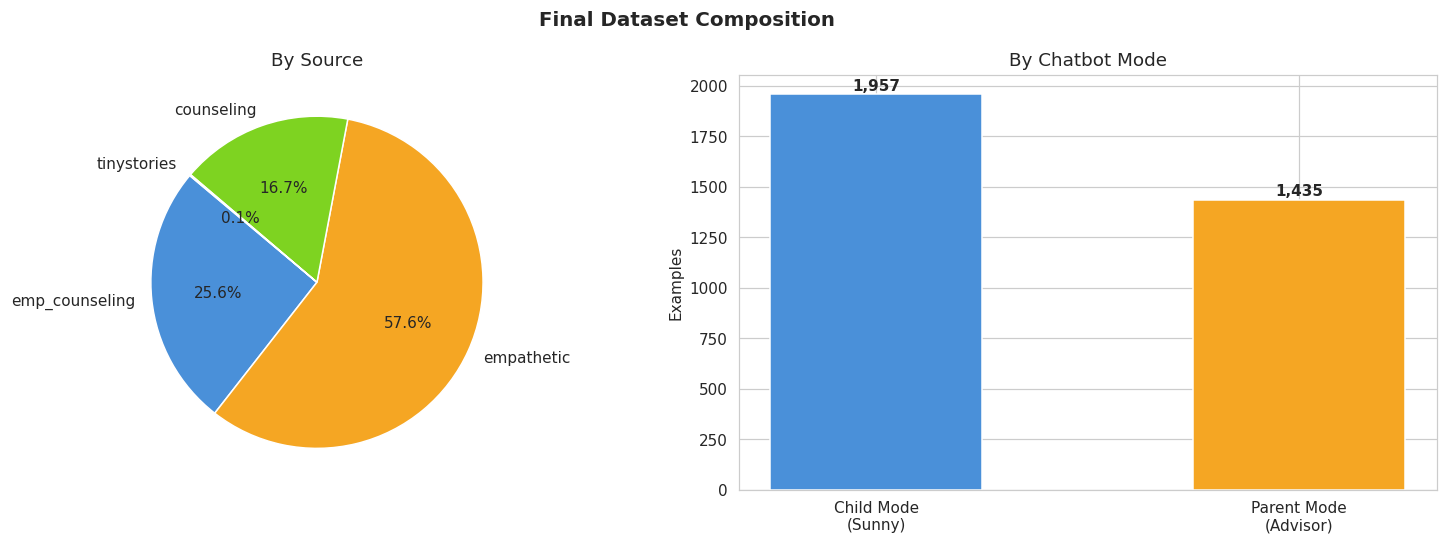

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(" Final Dataset Composition", fontsize=13, fontweight="bold")
labels, sizes = list(src_counts.keys()), list(src_counts.values())
ax1.pie(
    sizes,
    labels=labels,
    colors=PALETTE[: len(labels)],
    autopct="%1.1f%%",
    startangle=140,
)
ax1.set_title("By Source")
child_s = {"empathetic", "everyday", "children_stories", "tinystories"}
parent_s = {"counseling", "emp_counseling"}
cc = sum(v for k, v in src_counts.items() if k in child_s)
pc = sum(v for k, v in src_counts.items() if k in parent_s)
bars = ax2.bar(
    ["Child Mode\n(Sunny)", "Parent Mode\n(Advisor)"],
    [cc, pc],
    color=[PALETTE[0], PALETTE[1]],
    edgecolor="white",
    width=0.5,
)
ax2.set_title("By Chatbot Mode")
ax2.set_ylabel("Examples")
for b in bars:
    ax2.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 20,
        f"{int(b.get_height()):,}",
        ha="center",
        fontweight="bold",
    )
plt.tight_layout()
plt.savefig("dataset_composition.png", bbox_inches="tight")
plt.show()

---
## CELL 7 — Quality Validation & Save

In [ ]:
def validate(r):
    msgs = r.get("messages", [])
    if len(msgs) < 3:
        return False
    roles = [m["role"] for m in msgs]
    if roles[0] != "system" or "user" not in roles or "assistant" not in roles:
        return False
    return all(m.get("content", "").strip() for m in msgs)


valid = [r for r in deduped if validate(r)]
print(f" Valid: {len(valid):,} Invalid: {len(deduped)-len(valid):,}")

random.shuffle(valid)
split = int(len(valid) * 0.95)
train_data, val_data = valid[:split], valid[split:]
print(f"Train: {len(train_data):,} Val: {len(val_data):,}")


def save_jsonl(records, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f" Saved {len(records):,} → {path}")


save_jsonl(train_data, "smartchild_train.jsonl")
save_jsonl(val_data, "smartchild_val.jsonl")
save_jsonl(valid, "smartchild_final_dataset.jsonl")

 Valid: 3,392 Invalid: 0
Train: 3,222 Val: 170
 Saved 3,222 → smartchild_train.jsonl
 Saved 170 → smartchild_val.jsonl
 Saved 3,392 → smartchild_final_dataset.jsonl


---
## CELL 8 — Load Model + LoRA

In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=CFG["model_name"],
    max_seq_length=CFG["max_seq_length"],
    dtype=None,
    load_in_4bit=CFG["load_in_4bit"],
)
print(f' Model loaded: {CFG["model_name"]}')

model = FastLanguageModel.get_peft_model(
    model,
    r=CFG["lora_r"],
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=CFG["lora_alpha"],
    lora_dropout=CFG["lora_dropout"],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f" LoRA added — Trainable: {trainable:,} ({100*trainable/total:.2f}%)")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.1: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

...

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


 Model loaded: Qwen/Qwen2.5-1.5B-Instruct


Unsloth 2026.6.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


 LoRA added — Trainable: 18,464,768 (1.78%)


---
## CELL 9 — Tokenize & Train

In [ ]:
def fmt(ex):
    return {
        "text": tokenizer.apply_chat_template(
            ex["messages"], tokenize=False, add_generation_prompt=False
        )
    }


train_hf = Dataset.from_list([{"messages": r["messages"]} for r in train_data])
val_hf = Dataset.from_list([{"messages": r["messages"]} for r in val_data])
train_hf = train_hf.map(fmt, remove_columns=["messages"], desc="Formatting train")
val_hf = val_hf.map(fmt, remove_columns=["messages"], desc="Formatting val")
print(f" Train:{len(train_hf):,} Val:{len(val_hf):,}")
print(f'\nSample:\n{train_hf[0]["text"][:400]}')

Formatting train:   0%|          | 0/3222 [00:00<?, ? examples/s]

Formatting val:   0%|          | 0/170 [00:00<?, ? examples/s]

 Train:3,222 Val:170

Sample:
<|im_start|>system
You are a warm child development advisor for SmartChild. Speak with parents in plain language. Max 4 sentences. Never diagnose. Always offer to help further.<|im_end|>
<|im_start|>user
When I am laying with my wife, i dint think there is anything else more in the world i could need.<|im_end|>
<|im_start|>assistant
That's so sweet<|im_end|>



In [ ]:
from trl import SFTTrainer
from trl import SFTConfig

args = SFTConfig(
    dataset_num_proc=2,
    dataset_text_field="text",
    max_seq_length=CFG["max_seq_length"],
    output_dir=CFG["output_dir"],
    num_train_epochs=CFG["epochs"],
    per_device_train_batch_size=CFG["batch_size"],
    per_device_eval_batch_size=CFG["batch_size"],
    gradient_accumulation_steps=CFG["grad_accum"],
    warmup_ratio=CFG["warmup_ratio"],
    weight_decay=CFG["weight_decay"],
    learning_rate=CFG["lr"],
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    seed=42,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    args=args,
)

print(" Trainer ready")
steps_per_epoch = len(train_hf) // (CFG["batch_size"] * CFG["grad_accum"])
print(f' Steps/epoch: {steps_per_epoch:,} Total: {steps_per_epoch*CFG["epochs"]:,}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/3222 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/170 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
 Trainer ready
 Steps/epoch: 402 Total: 2,010


In [ ]:
print(" Starting fine-tuning...\n" + "=" * 60)
result = trainer.train()
print("=" * 60)
print(
    f' Done! Loss: {result.training_loss:.4f} Time: {result.metrics["train_runtime"]/60:.1f} min'
)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


 Starting fine-tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,222 | Num Epochs = 5 | Total steps = 2,015
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,1.397969,1.377550
2,1.310581,1.381796
3,1.061965,1.463490
4,0.721114,1.679848
5,0.656405,1.873084


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in ./smartchild-model/checkpoint-403/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./smartchild-model/checkpoint-806/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./smartchild-model/checkpoint-1209/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./smartchild-model/checkpoint-1612/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./smartchild-model/checkpoint-2015/tokenizer_config.json.


 Done! Loss: 1.0787 Time: 76.7 min


---
## CELL 10 — Training Curves & Qualitative Eval

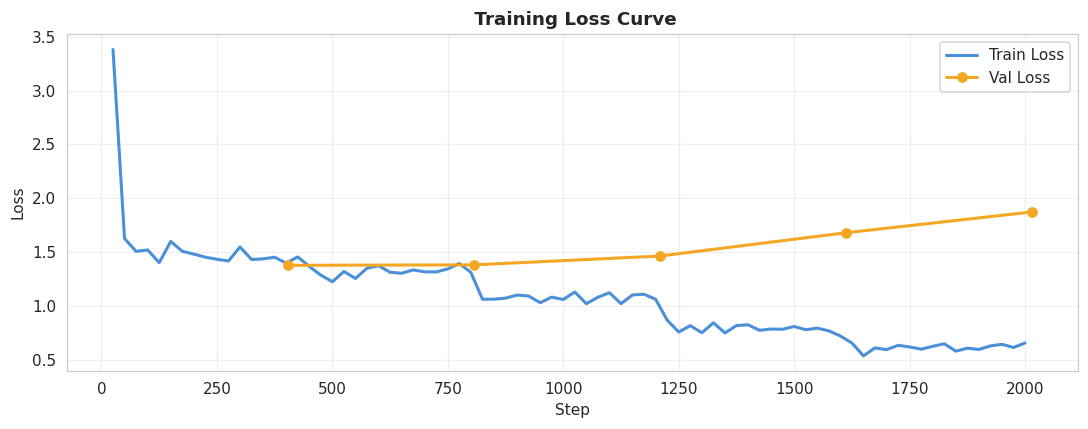

In [ ]:
log = trainer.state.log_history
ts = [x["step"] for x in log if "loss" in x]
tl = [x["loss"] for x in log if "loss" in x]
es = [x["step"] for x in log if "eval_loss" in x]
el = [x["eval_loss"] for x in log if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts, tl, color=PALETTE[0], label="Train Loss", linewidth=2)
if el:
    ax.plot(es, el, color=PALETTE[1], label="Val Loss", linewidth=2, marker="o")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(" Training Loss Curve", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", bbox_inches="tight")
plt.show()

In [ ]:
FastLanguageModel.for_inference(model)


def chat(system, user, max_t=150):
    msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    text = tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True
    )
    inp = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inp,
            max_new_tokens=max_t,
            temperature=0.7,
            do_sample=True,
            repetition_penalty=1.1,
        )
    return tokenizer.decode(
        out[0][inp["input_ids"].shape[1] :], skip_special_tokens=True
    ).strip()


CHILD_SYS = "You are Sunny in SmartChild. Max 2 short sentences. Simple words. Always encouraging."

print("=" * 60 + "\n CHILD MODE TESTS\n" + "=" * 60)
for msg, emo in [
    ("I finished all my games today!", "happy"),
    ("I feel sad today.", "sad"),
    ("This game is too hard!", "angry"),
    ("Tell me a short story!", "happy")
]:
    r = chat(CHILD_SYS + f" Child feels {emo}.", msg, 80)
    print(f"\n {msg}\n {r}")

print("\n" + "=" * 60 + "\n PARENT MODE TESTS\n" + "=" * 60)
for msg in [
    "My child scored low in color recognition, what should I do?",
    "Ahmed seems sad in his drawings, is that concerning?",
    "What activities help with reaction speed?"
]:
    r = chat(
        "You are a warm child development advisor for SmartChild. Max 4 sentences. Never diagnose.",
        msg,
    )
    print(f"\n {msg}\n {r}")

Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 CHILD MODE TESTS


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 I finished all my games today!
 That's good, what were you playing?


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


 Tell me a short story!
 I can't believe how many people have to pay for their car insurance. I feel like it's unfair because the company is not responsible for everything.

 PARENT MODE TESTS


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 My child scored low in color recognition, what should I do?
 I would start by asking her if she can see the colors and is it possible that she's just not used to being asked to identify them yet. If you have any concerns about this or if you're worried your child may be having difficulty with other aspects of learning then you might want to consider enrolling her in an early childhood education program which will help her learn at her own pace.


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



 Ahmed seems sad in his drawings, is that concerning?
 It's important to be aware of our emotions and how they may impact others. If Ahmed's sadness affects your ability to interact with him or causes any harm, it would be wise to discuss this with him and consider seeking support from a mental health professional if necessary.

 What activities help with reaction speed?
 It's difficult to know what is best without knowing more about your specific situation and the reason why you want to improve your reaction time. If you're interested in improving your reaction time, then try some of these activities: playing sports like basketball or football, doing puzzles, practicing typing on a keyboard, learning how to drive, taking online courses or classes, listening to music while exercising, trying out new foods, etc. There are many ways to improve your reaction time!


---
## CELL 11 — Save Model

In [ ]:
model.save_pretrained(CFG["output_dir"])
tokenizer.save_pretrained(CFG["output_dir"])

import os
import shutil

for f in os.listdir(CFG["output_dir"]):
    print(f" {f}")

try:
    from google.colab import files
    zip_path = shutil.make_archive(CFG["output_dir"], 'zip', CFG["output_dir"])
    files.download(zip_path)
except:
    pass

Unsloth: Restored added_tokens_decoder metadata in ./smartchild-model/tokenizer_config.json.


 tokenizer.json
 tokenizer_config.json
 adapter_model.safetensors
 checkpoint-1612
 README.md
 chat_template.jinja
 checkpoint-403
 checkpoint-2015
 checkpoint-806
 checkpoint-1209
 adapter_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## CELL 14 — Final Summary

In [ ]:
print("=" * 60)
print(" SMARTCHILD CHATBOT — PIPELINE COMPLETE")
print("=" * 60)
print(f' Base model : {CFG["model_name"]}')
print(f" Train examples : {len(train_data):,}")
print(f" Val examples : {len(val_data):,}")
print(f" Final loss : {result.training_loss:.4f}")
print()
print("Files generated in this Colab session:")
for f in [
    "smartchild-model/",
    "smartchild_train.jsonl",
    "smartchild_val.jsonl",
    "smartchild_final_dataset.jsonl",
    "training_curve.png",
    "dataset_composition.png",
    "word_distributions.png",
]:
    print(f" {f}")

 SMARTCHILD CHATBOT — PIPELINE COMPLETE
 Base model : Qwen/Qwen2.5-1.5B-Instruct
 Train examples : 3,222
 Val examples : 170
 Final loss : 1.0787

Files generated in this Colab session:
 smartchild-model/
 smartchild_train.jsonl
 smartchild_val.jsonl
 smartchild_final_dataset.jsonl
 training_curve.png
 dataset_composition.png
 word_distributions.png
